# Percobaan 03: Klasifikasi Citra
Notebook ini berisi proses klasifikasi citra berdasarkan fitur tekstur GLCM yang telah disimpan dalam file CSV. Setiap hasil preprocessing diuji menggunakan beberapa model klasifikasi untuk melihat pengaruh preprocessing terhadap performa model. Alur kerja meliputi pembacaan fitur, seleksi fitur, pembagian data, normalisasi, pelatihan model, evaluasi, dan visualisasi hasil. Hasil akhir digunakan untuk menentukan kombinasi preprocessing dan model dengan akurasi terbaik.


## Import Library
Bagian ini mengimpor library yang dibutuhkan untuk membaca data, mengolah tabel, melatih model, mengevaluasi hasil, dan membuat visualisasi. Library `pathlib` digunakan untuk mengatur lokasi file hasil ekstraksi dan output klasifikasi. Library `numpy` dan `pandas` digunakan untuk operasi numerik serta pengolahan dataset fitur. Library `matplotlib` dan `seaborn` digunakan untuk membuat grafik dan heatmap korelasi fitur. Library dari `sklearn` digunakan untuk membagi dataset, membangun model Random Forest, SVM, dan KNN, serta menghitung metrik evaluasi seperti accuracy, precision, recall, F1-score, dan confusion matrix.


In [27]:
# Import library yang dibutuhkan
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


## Konfigurasi Folder dan Model
Bagian ini menentukan lokasi folder `hasil_ekstraksi` sebagai input dan folder `hasil_klasifikasi` sebagai tempat penyimpanan output. Folder output dibuat otomatis jika belum tersedia agar file ringkasan hasil dapat langsung disimpan. Dictionary `PREPO_CONFIG` menghubungkan setiap metode preprocessing dengan file CSV hasil ekstraksi fiturnya. Program menampilkan path folder yang digunakan agar lokasi input dan output dapat diverifikasi. Setiap file CSV juga dicek keberadaannya sehingga proses klasifikasi tidak langsung gagal tanpa informasi yang jelas.


In [28]:
# Folder input: hasil ekstraksi fitur
EKSTRAKSI_DIR = Path("../hasil_ekstraksi")

# Folder output: hasil klasifikasi
KLASIFIKASI_DIR = Path("../hasil_klasifikasi")
KLASIFIKASI_DIR.mkdir(parents=True, exist_ok=True)

# Mapping nama preprocessing dan file CSV hasil ekstraksi
PREPO_CONFIG = {
    "prepo1_resize+grayscale": "hasil_ekstraksi_prepo1.csv",
    "prepo2_resize+grayscale+median": "hasil_ekstraksi_prepo2.csv",
    "prepo3_resize+grayscale+median+equ": "hasil_ekstraksi_prepo3.csv",
    "prepo4_resize+grayscale+median+sobel": "hasil_ekstraksi_prepo4.csv",
    "prepo5_resize+grayscale+median+sobel+thresholding": "hasil_ekstraksi_prepo5.csv"
}

print("Folder hasil ekstraksi:", EKSTRAKSI_DIR.resolve())
print("Folder hasil klasifikasi:", KLASIFIKASI_DIR.resolve())

print("\nCek file CSV:")
for prepo_name, csv_name in PREPO_CONFIG.items():
    csv_path = EKSTRAKSI_DIR / csv_name
    print(prepo_name, "->", "ADA" if csv_path.exists() else "TIDAK ADA", "|", csv_path)


Folder hasil ekstraksi: D:\AAAAA KULIAH\SEM 4\PECEDE\Project-PCD-Kelompok-16\hasil_ekstraksi
Folder hasil klasifikasi: D:\AAAAA KULIAH\SEM 4\PECEDE\Project-PCD-Kelompok-16\hasil_klasifikasi

Cek file CSV:
prepo1_resize+grayscale -> ADA | ..\hasil_ekstraksi\hasil_ekstraksi_prepo1.csv
prepo2_resize+grayscale+median -> ADA | ..\hasil_ekstraksi\hasil_ekstraksi_prepo2.csv
prepo3_resize+grayscale+median+equ -> ADA | ..\hasil_ekstraksi\hasil_ekstraksi_prepo3.csv
prepo4_resize+grayscale+median+sobel -> ADA | ..\hasil_ekstraksi\hasil_ekstraksi_prepo4.csv
prepo5_resize+grayscale+median+sobel+thresholding -> ADA | ..\hasil_ekstraksi\hasil_ekstraksi_prepo5.csv


## Fungsi Laporan Klasifikasi
Fungsi `generateClassificationReport()` digunakan untuk menampilkan hasil evaluasi prediksi model. Fungsi ini mencetak `classification_report` yang berisi precision, recall, F1-score, dan support untuk setiap kelas. Selain itu, fungsi juga menampilkan confusion matrix untuk melihat jumlah prediksi benar dan salah. Nilai accuracy ditampilkan secara terpisah agar performa umum model dapat langsung diketahui. Fungsi ini dipakai pada data latih dan data uji sehingga perbandingan performa keduanya lebih mudah diamati.


In [29]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true, y_pred))


## Seleksi Fitur Berdasarkan Korelasi
Fungsi `feature_selection_template()` digunakan untuk memilih fitur numerik yang tidak memiliki korelasi terlalu tinggi satu sama lain. Kolom non-fitur seperti `Label`, `Filename`, dan `Preprocessing` dihapus terlebih dahulu agar tidak ikut dihitung dalam korelasi. Matriks korelasi dibuat dari fitur numerik, lalu fitur dengan korelasi lebih besar atau sama dengan threshold akan disaring. Threshold default 0.95 digunakan untuk mengurangi fitur yang sangat mirip tanpa menghapus terlalu banyak informasi. Fungsi ini mengembalikan data fitur terpilih, label target, dan daftar nama fitur yang digunakan. Jika `show_heatmap` bernilai benar, heatmap korelasi fitur akan ditampilkan untuk membantu analisis visual.


In [30]:
def feature_selection_template(hasilEkstrak, threshold=0.95, show_heatmap=False, title="Korelasi Fitur"):
    # Kolom yang bukan fitur
    drop_columns = ["Label", "Filename", "Preprocessing"]
    drop_columns = [col for col in drop_columns if col in hasilEkstrak.columns]

    # Ambil fitur numerik
    feature_data = hasilEkstrak.drop(columns=drop_columns)
    feature_data = feature_data.select_dtypes(include=[np.number])

    # Menghitung korelasi
    correlation_matrix = feature_data.corr()

    # Menyaring fitur yang memiliki korelasi lebih dari threshold
    columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)

    for i in range(correlation_matrix.shape[0]):
        for j in range(i + 1, correlation_matrix.shape[0]):
            if correlation_matrix.iloc[i, j] >= threshold:
                if columns[j]:
                    columns[j] = False

    selected_columns = feature_data.columns[columns]

    x_new = hasilEkstrak[selected_columns]
    y = hasilEkstrak["Label"]

    if show_heatmap:
        plt.figure(figsize=(17, 17))
        sns.heatmap(x_new.corr(), annot=True, cmap="Blues", fmt=".2f")
        plt.title(title)
        plt.show()

    return x_new, y, selected_columns


## Normalisasi Data
Fungsi `normalisasi_mean_std()` digunakan untuk menstandarkan nilai fitur pada data latih dan data uji. Rata-rata dan standar deviasi dihitung dari data latih agar informasi dari data uji tidak bocor ke proses pelatihan. Setiap nilai fitur dikurangi rata-rata data latih, lalu dibagi dengan standar deviasi data latih. Jika ada fitur dengan standar deviasi nol, nilainya diganti menjadi satu untuk menghindari pembagian dengan nol. Normalisasi ini membantu model seperti SVM dan KNN bekerja lebih stabil karena skala fitur menjadi seragam.


In [31]:
def normalisasi_mean_std(X_train, X_test):
    # Menghindari pembagian dengan 0 jika ada fitur yang standar deviasinya 0
    std_train = X_train.std().replace(0, 1)

    X_test_norm = (X_test - X_train.mean()) / std_train
    X_train_norm = (X_train - X_train.mean()) / std_train

    return X_train_norm, X_test_norm


## Klasifikasi Satu Metode Preprocessing
Fungsi `klasifikasi_satu_prepo()` menjalankan seluruh proses klasifikasi untuk satu file CSV hasil ekstraksi fitur. Data dibaca menggunakan `pandas`, lalu jumlah data dan distribusi label ditampilkan untuk memeriksa komposisi dataset. Setelah itu dilakukan seleksi fitur berdasarkan korelasi, pembagian data latih dan data uji dengan stratifikasi label, serta normalisasi mean dan standar deviasi. Model yang digunakan adalah Random Forest, SVM, dan KNN, lalu masing-masing model dilatih dan dievaluasi pada data latih serta data uji. Metrik seperti accuracy, precision, recall, F1-score, jumlah data, dan jumlah fitur disimpan dalam DataFrame ringkasan. Fungsi juga menyimpan model terlatih dan hasil prediksi agar dapat digunakan kembali untuk visualisasi confusion matrix.


In [32]:
def klasifikasi_satu_prepo(prepo_name, csv_path, show_heatmap=False):
    print("=" * 80)
    print("Preprocessing:", prepo_name)
    print("CSV:", csv_path)
    print("=" * 80)

    # Membaca hasil ekstraksi fitur
    hasilEkstrak = pd.read_csv(csv_path)

    print("Jumlah data:", len(hasilEkstrak))
    print("Distribusi label:")
    print(hasilEkstrak["Label"].value_counts())
    print()

    # Feature selection
    x_new, y, selected_columns = feature_selection_template(
        hasilEkstrak,
        threshold=0.95,
        show_heatmap=show_heatmap,
        title=f"Korelasi Fitur - {prepo_name}"
    )

    print("Jumlah fitur awal:", len([
        col for col in hasilEkstrak.columns
        if col not in ["Label", "Filename", "Preprocessing"]
    ]))
    print("Jumlah fitur setelah selection:", len(selected_columns))
    print("Fitur yang digunakan:")
    print(list(selected_columns))
    print()

    # Splitting data
    X_train, X_test, y_train, y_test = train_test_split(
        x_new,
        y,
        test_size=0.2,
        random_state=64,
        stratify=y
    )

    print("Shape X_train:", X_train.shape)
    print("Shape X_test:", X_test.shape)
    print()

    # Normalisasi mean std
    X_train, X_test = normalisasi_mean_std(X_train, X_test)

    # Define classifiers sesuai template
    models = {
        "Random Forest": RandomForestClassifier(n_estimators=5, random_state=42),
        "SVM": SVC(kernel="rbf", random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5)
    }

    hasil_model = []
    trained_models = {}
    predictions = {}

    for model_name, model in models.items():
        print("-" * 80)
        print("Model:", model_name)
        print("-" * 80)

        # Train model
        model.fit(X_train, y_train)
        trained_models[model_name] = model

        # Evaluasi training set
        print("------Training Set------")
        y_pred_train = model.predict(X_train)
        generateClassificationReport(y_train, y_pred_train)

        # Evaluasi testing set
        print("\n------Testing Set------")
        y_pred_test = model.predict(X_test)
        generateClassificationReport(y_test, y_pred_test)

        predictions[model_name] = {
            "y_test": y_test,
            "y_pred_test": y_pred_test
        }

        hasil_model.append({
            "Preprocessing": prepo_name,
            "Model": model_name,
            "Train Accuracy": accuracy_score(y_train, y_pred_train),
            "Test Accuracy": accuracy_score(y_test, y_pred_test),
            "Precision": precision_score(y_test, y_pred_test, average="weighted", zero_division=0),
            "Recall": recall_score(y_test, y_pred_test, average="weighted", zero_division=0),
            "F1-Score": f1_score(y_test, y_pred_test, average="weighted", zero_division=0),
            "Total Data": len(hasilEkstrak),
            "Jumlah Fitur Awal": len([
                col for col in hasilEkstrak.columns
                if col not in ["Label", "Filename", "Preprocessing"]
            ]),
            "Jumlah Fitur Setelah Selection": len(selected_columns)
        })

        print()

    result_df = pd.DataFrame(hasil_model)

    return {
        "prepo_name": prepo_name,
        "data": hasilEkstrak,
        "x_new": x_new,
        "y": y,
        "selected_columns": selected_columns,
        "result_df": result_df,
        "trained_models": trained_models,
        "predictions": predictions,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }


## Menjalankan Klasifikasi Semua Metode
Bagian ini menjalankan fungsi klasifikasi untuk setiap metode preprocessing yang ada pada `PREPO_CONFIG`. Program memeriksa keberadaan file CSV sebelum menjalankan klasifikasi agar file yang hilang dapat dilewati dengan pesan yang jelas. Hasil klasifikasi setiap preprocessing disimpan dalam dictionary `hasil_semua_prepo`. Ringkasan performa setiap model dikumpulkan dalam list `ringkasan_klasifikasi`. Semua ringkasan kemudian digabungkan menjadi `df_ringkasan` sehingga perbandingan seluruh kombinasi preprocessing dan model dapat dilihat dalam satu tabel.


In [33]:
hasil_semua_prepo = {}
ringkasan_klasifikasi = []

for prepo_name, csv_name in PREPO_CONFIG.items():
    csv_path = EKSTRAKSI_DIR / csv_name

    if not csv_path.exists():
        print(f"File tidak ditemukan: {csv_path}")
        continue

    hasil = klasifikasi_satu_prepo(prepo_name, csv_path, show_heatmap=False)
    hasil_semua_prepo[prepo_name] = hasil
    ringkasan_klasifikasi.append(hasil["result_df"])

df_ringkasan = pd.concat(ringkasan_klasifikasi, ignore_index=True)

df_ringkasan


Preprocessing: prepo1_resize+grayscale
CSV: ..\hasil_ekstraksi\hasil_ekstraksi_prepo1.csv
Jumlah data: 140
Distribusi label:
Label
catterpillar    70
snail           70
Name: count, dtype: int64

Jumlah fitur awal: 28
Jumlah fitur setelah selection: 10
Fitur yang digunakan:
['Contrast0', 'Homogeneity0', 'Dissimilarity0', 'Entropy0', 'ASM0', 'Energy0', 'Correlation0', 'Contrast45', 'Dissimilarity45', 'Correlation45']

Shape X_train: (112, 10)
Shape X_test: (28, 10)

--------------------------------------------------------------------------------
Model: Random Forest
--------------------------------------------------------------------------------
------Training Set------
              precision    recall  f1-score   support

catterpillar       1.00      0.96      0.98        56
       snail       0.97      1.00      0.98        56

    accuracy                           0.98       112
   macro avg       0.98      0.98      0.98       112
weighted avg       0.98      0.98      0.98       

,Preprocessing,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,Total Data,Jumlah Fitur Awal,Jumlah Fitur Setelah Selection
0,prepo1_resize+grayscale,Random Forest,0.982143,0.928571,0.928571,0.928571,0.928571,140,28,10
1,prepo1_resize+grayscale,SVM,0.875000,0.928571,0.937500,0.928571,0.928205,140,28,10
2,prepo1_resize+grayscale,KNN,0.839286,0.892857,0.894872,0.892857,0.892720,140,28,10
3,prepo2_resize+grayscale+median,Random Forest,0.964286,0.928571,0.928571,0.928571,0.928571,140,28,14
4,prepo2_resize+grayscale+median,SVM,0.866071,0.892857,0.894872,0.892857,0.892720,140,28,14
5,prepo2_resize+grayscale+median,KNN,0.892857,0.857143,0.857143,0.857143,0.857143,140,28,14
6,prepo3_resize+grayscale+median+equ,Random Forest,0.955357,0.714286,0.714286,0.714286,0.714286,140,28,12
7,prepo3_resize+grayscale+median+equ,SVM,0.875000,0.821429,0.836898,0.821429,0.819355,140,28,12
8,prepo3_resize+grayscale+median+equ,KNN,0.857143,0.821429,0.836898,0.821429,0.819355,140,28,12
9,prepo4_resize+grayscale+median+sobel,Random Forest,0.955357,0.750000,0.762032,0.750000,0.747097,140,28,14


## Menyimpan Ringkasan Hasil
Bagian ini menyimpan tabel `df_ringkasan` ke dalam file CSV bernama `hasil_klasifikasi_semua_prepo.csv`. File tersebut ditempatkan pada folder `hasil_klasifikasi` agar hasil evaluasi terpisah dari file ekstraksi fitur. Ringkasan yang disimpan mencakup nama preprocessing, nama model, akurasi latih, akurasi uji, precision, recall, F1-score, jumlah data, dan jumlah fitur. Penyimpanan ini membuat hasil percobaan dapat dibuka kembali tanpa menjalankan ulang seluruh proses klasifikasi. Setelah penyimpanan selesai, path file ditampilkan sebagai konfirmasi lokasi output.


In [34]:
output_ringkasan = KLASIFIKASI_DIR / "hasil_klasifikasi_semua_prepo.csv"
df_ringkasan.to_csv(output_ringkasan, index=False)

print("Hasil klasifikasi berhasil disimpan ke:", output_ringkasan.resolve())
df_ringkasan


Hasil klasifikasi berhasil disimpan ke: D:\AAAAA KULIAH\SEM 4\PECEDE\Project-PCD-Kelompok-16\hasil_klasifikasi\hasil_klasifikasi_semua_prepo.csv


,Preprocessing,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score,Total Data,Jumlah Fitur Awal,Jumlah Fitur Setelah Selection
0,prepo1_resize+grayscale,Random Forest,0.982143,0.928571,0.928571,0.928571,0.928571,140,28,10
1,prepo1_resize+grayscale,SVM,0.875000,0.928571,0.937500,0.928571,0.928205,140,28,10
2,prepo1_resize+grayscale,KNN,0.839286,0.892857,0.894872,0.892857,0.892720,140,28,10
3,prepo2_resize+grayscale+median,Random Forest,0.964286,0.928571,0.928571,0.928571,0.928571,140,28,14
4,prepo2_resize+grayscale+median,SVM,0.866071,0.892857,0.894872,0.892857,0.892720,140,28,14
5,prepo2_resize+grayscale+median,KNN,0.892857,0.857143,0.857143,0.857143,0.857143,140,28,14
6,prepo3_resize+grayscale+median+equ,Random Forest,0.955357,0.714286,0.714286,0.714286,0.714286,140,28,12
7,prepo3_resize+grayscale+median+equ,SVM,0.875000,0.821429,0.836898,0.821429,0.819355,140,28,12
8,prepo3_resize+grayscale+median+equ,KNN,0.857143,0.821429,0.836898,0.821429,0.819355,140,28,12
9,prepo4_resize+grayscale+median+sobel,Random Forest,0.955357,0.750000,0.762032,0.750000,0.747097,140,28,14


## Tabel Akurasi
Bagian ini membuat salinan `df_ringkasan` untuk menampilkan akurasi dalam bentuk persen. Kolom `Test Accuracy` dan `Train Accuracy` dikalikan 100 agar lebih mudah dibaca dalam tabel laporan. Tabel tampilan hanya mengambil kolom penting seperti preprocessing, model, akurasi latih, akurasi uji, precision, recall, dan F1-score. Penyusunan tabel ini membantu membandingkan performa antar model secara ringkas. Data pada bagian ini menjadi dasar awal untuk melihat model mana yang memiliki performa uji paling tinggi.


In [35]:
df_akurasi = df_ringkasan.copy()
df_akurasi["Test Accuracy (%)"] = df_akurasi["Test Accuracy"] * 100
df_akurasi["Train Accuracy (%)"] = df_akurasi["Train Accuracy"] * 100

df_akurasi_tampil = df_akurasi[[
    "Preprocessing",
    "Model",
    "Train Accuracy (%)",
    "Test Accuracy (%)",
    "Precision",
    "Recall",
    "F1-Score"
]]

df_akurasi_tampil


,Preprocessing,Model,Train Accuracy (%),Test Accuracy (%),Precision,Recall,F1-Score
0,prepo1_resize+grayscale,Random Forest,98.214286,92.857143,0.928571,0.928571,0.928571
1,prepo1_resize+grayscale,SVM,87.500000,92.857143,0.937500,0.928571,0.928205
2,prepo1_resize+grayscale,KNN,83.928571,89.285714,0.894872,0.892857,0.892720
3,prepo2_resize+grayscale+median,Random Forest,96.428571,92.857143,0.928571,0.928571,0.928571
4,prepo2_resize+grayscale+median,SVM,86.607143,89.285714,0.894872,0.892857,0.892720
5,prepo2_resize+grayscale+median,KNN,89.285714,85.714286,0.857143,0.857143,0.857143
6,prepo3_resize+grayscale+median+equ,Random Forest,95.535714,71.428571,0.714286,0.714286,0.714286
7,prepo3_resize+grayscale+median+equ,SVM,87.500000,82.142857,0.836898,0.821429,0.819355
8,prepo3_resize+grayscale+median+equ,KNN,85.714286,82.142857,0.836898,0.821429,0.819355
9,prepo4_resize+grayscale+median+sobel,Random Forest,95.535714,75.000000,0.762032,0.750000,0.747097


## Identifikasi Model Terbaik
Bagian ini memilih baris dengan nilai `Test Accuracy` tertinggi dari `df_ringkasan`. Hasil yang dipilih dianggap sebagai kombinasi preprocessing dan model terbaik berdasarkan performa pada data uji. Informasi yang ditampilkan meliputi nama preprocessing, nama model, akurasi uji, precision, recall, dan F1-score. Nilai akurasi diubah ke persen agar lebih mudah dipahami. Precision, recall, dan F1-score tetap ditampilkan untuk memastikan model terbaik tidak hanya dilihat dari accuracy saja.


In [36]:
best_result = df_ringkasan.loc[df_ringkasan["Test Accuracy"].idxmax()]

print("Model terbaik:")
print("Preprocessing :", best_result["Preprocessing"])
print("Model         :", best_result["Model"])
print("Akurasi Test  :", round(best_result["Test Accuracy"] * 100, 2), "%")
print("Precision     :", round(best_result["Precision"], 4))
print("Recall        :", round(best_result["Recall"], 4))
print("F1-Score      :", round(best_result["F1-Score"], 4))


Model terbaik:
Preprocessing : prepo1_resize+grayscale
Model         : Random Forest
Akurasi Test  : 92.86 %
Precision     : 0.9286
Recall        : 0.9286
F1-Score      : 0.9286


## Fungsi Visualisasi Confusion Matrix
Fungsi `plot_confusion_matrix()` digunakan untuk menampilkan confusion matrix dari hasil prediksi model. Confusion matrix membantu melihat kelas mana yang banyak diprediksi benar dan kelas mana yang sering tertukar. Setelah model terbaik berdasarkan preprocessing ditemukan, program mengambil semua prediksi model pada preprocessing tersebut. Setiap model kemudian divisualisasikan menggunakan warna biru agar pola prediksi lebih mudah diamati. Visualisasi ini menjadi pelengkap metrik numerik karena menunjukkan detail kesalahan klasifikasi antar kelas.


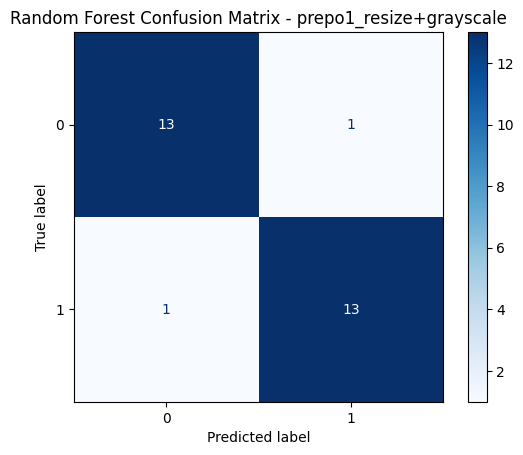

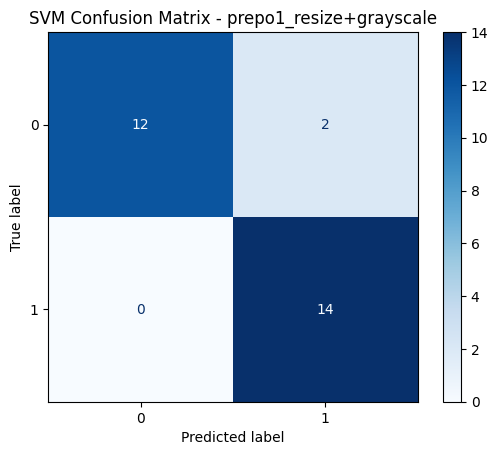

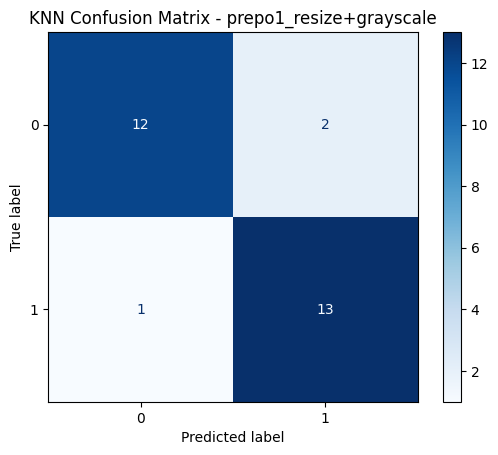

In [37]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()


best_prepo = best_result["Preprocessing"]
hasil_best = hasil_semua_prepo[best_prepo]

for model_name, pred_data in hasil_best["predictions"].items():
    plot_confusion_matrix(
        pred_data["y_test"],
        pred_data["y_pred_test"],
        f"{model_name} Confusion Matrix - {best_prepo}"
    )


## Visualisasi Perbandingan Akurasi
Bagian ini membuat grafik batang untuk membandingkan akurasi uji dari seluruh kombinasi preprocessing dan model. Kolom `Kombinasi` dibuat dari gabungan nama preprocessing dan nama model agar setiap batang memiliki label yang jelas. Nilai akurasi uji dikonversi ke persen sebelum divisualisasikan. Label sumbu X diputar 90 derajat supaya teks yang panjang tidak saling bertumpuk. Grafik ini memudahkan analisis visual terhadap kombinasi yang memiliki performa tinggi maupun rendah.


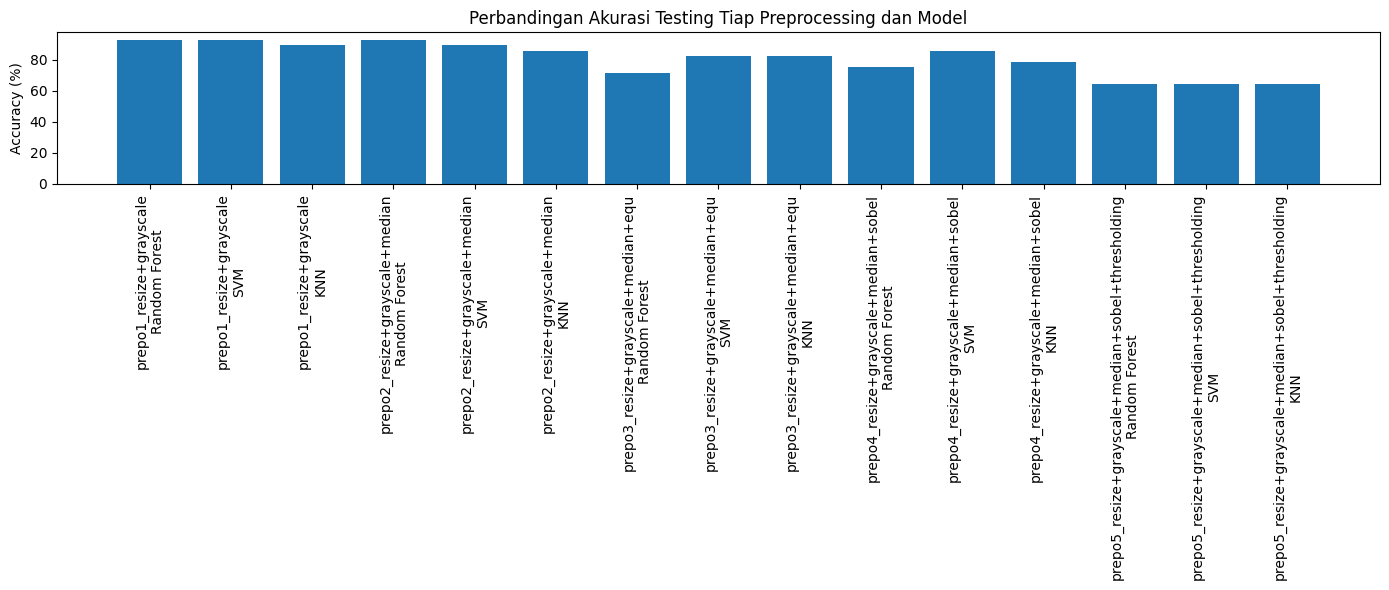

In [38]:
plt.figure(figsize=(14, 6))

plot_data = df_ringkasan.copy()
plot_data["Kombinasi"] = plot_data["Preprocessing"] + "\n" + plot_data["Model"]
plot_data["Test Accuracy (%)"] = plot_data["Test Accuracy"] * 100

plt.bar(plot_data["Kombinasi"], plot_data["Test Accuracy (%)"])
plt.xticks(rotation=90)
plt.ylabel("Accuracy (%)")
plt.title("Perbandingan Akurasi Testing Tiap Preprocessing dan Model")
plt.tight_layout()
plt.show()


## Kesimpulan Hasil Klasifikasi
Bagian ini menampilkan kesimpulan akhir berdasarkan kombinasi dengan akurasi uji tertinggi. Informasi yang ditulis mencakup metode preprocessing terbaik, model klasifikasi yang digunakan, dan persentase akurasi testing. Kesimpulan dibuat secara otomatis dari `best_result` sehingga mengikuti hasil perhitungan pada tabel ringkasan. Output ini dapat digunakan sebagai kalimat ringkas untuk menjelaskan hasil utama percobaan. Bagian ini menjadi penutup dari alur klasifikasi karena merangkum temuan paling penting dari seluruh perbandingan model.


In [39]:
print(
    f"Berdasarkan hasil klasifikasi, kombinasi terbaik diperoleh pada "
    f"{best_result['Preprocessing']} menggunakan model {best_result['Model']} "
    f"dengan akurasi testing sebesar {best_result['Test Accuracy'] * 100:.2f}%."
)


Berdasarkan hasil klasifikasi, kombinasi terbaik diperoleh pada prepo1_resize+grayscale menggunakan model Random Forest dengan akurasi testing sebesar 92.86%.
